# Example: Registered Interest and Principal of Securities (STRIPS) Bonds
In this example, we separate a coupon Treasury security into zero-coupon [STRIPS](https://www.treasurydirect.gov/marketable-securities/strips/) and price the resulting cash flows from an issuer's perspective.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Generate STRIPS cash flows:__ Separate the coupon and principal payments of a selected Treasury security into individual zero-coupon claims. Verify that the number of claims matches the payment schedule of the parent security.
> * __Apply alternative pricing assumptions:__ Price the claims under constant-yield, constant-discount, and upward-sloping yield-curve scenarios. Connect each scheme's assumed discount structure to the strip prices it produces.
> * __Compare issuer pricing strategies:__ Explain how maturity-specific discount assumptions change the prices of the resulting securities. Use the reassembly check against the parent bond value to judge whether a pricing scheme is internally consistent.

We will construct the STRIPS and compare the three pricing strategies.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
# Load the notebook environment and local pricing helpers.
include(joinpath(@__DIR__, "Include.jl"));

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We'll explore `T-note` and `T-bond` prices from United States Treasury auctions since October 2022, downloaded using the [Auction query functionality of TreasuryDirect.gov](https://www.treasurydirect.gov/auctions/auction-query/) and vendored with the course package. 

> __Dataset:__ We load the dataset using [the `MyTreasuryNotesAndBondsDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryNotesAndBondsDataSet) exported by the `VLQuantitativeFinancePackage`, and store the auction records in the `dataset::DataFrame` variable. By default it returns original issues only; reopenings carry an existing security's coupon and so trade well away from par, and are available with `reopenings = true`.

So what do we have?

In [2]:
# Load the Treasury note and bond auction records used to select a parent security.
dataset = MyTreasuryNotesAndBondsDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Yield,Interest Rate
,String15,String7,String31,String15,String15,String15,Float64,Float64,Float64
1,912810UX4,Bond,20-Year,08/19/2026,08/31/2026,08/15/2046,99.0213,0.05204,0.05125
2,912810UW6,Bond,30-Year,08/13/2026,08/17/2026,08/15/2056,98.627,0.05216,0.05125
3,91282CRF0,Note,10-Year,08/12/2026,08/17/2026,08/15/2036,99.5407,0.04683,0.04625
4,91282CRG8,Note,3-Year,08/11/2026,08/17/2026,08/15/2029,99.8854,0.04291,0.0425
5,91282CRC7,Note,7-Year,07/28/2026,07/31/2026,07/31/2033,99.4165,0.04473,0.04375
6,91282CRB9,Note,2-Year,07/27/2026,07/31/2026,07/31/2028,99.8767,0.04315,0.0425
7,91282CRA1,Note,5-Year,07/27/2026,07/31/2026,07/31/2031,99.8534,0.04408,0.04375
8,91282CRE3,Note,10-Year,07/23/2026,07/31/2026,07/15/2036,99.7681,0.02438,0.02375
9,91282CQZ7,Note,3-Year,07/07/2026,07/15/2026,07/15/2029,99.8492,0.04179,0.04125


___

## Task 1: Select a random note or bond from which we create separate marketable products
In this task, we'll select a random note or bond, compute its price, compare it to the auction price (to check our pricing code), and then strip the selected note or bond.

First, let's determine how many notes and bonds we have in the `dataset::DataFrame` using the [nrow function](https://dataframes.juliadata.org/stable/lib/functions/#DataAPI.nrow) that is exported by the [DataFrames.jl package](https://github.com/JuliaData/DataFrames.jl). Then, we'll compute a random index using the [built-in Julia rand function](https://docs.julialang.org/en/v1/stdlib/Random/). We store the data for the random note or bond in the `random_note_or_bond_data::DataFrameRow` variable:

In [3]:
# Select one auction record to serve as the parent coupon security.
random_note_or_bond_data = let
    
    number_of_notes_and_bonds = nrow(dataset);
    i = rand(1:number_of_notes_and_bonds); # row index of the selected auction record
    random_note_or_bond = dataset[i,:];
    random_note_or_bond # Return the selected DataFrameRow.
end


Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Yield,Interest Rate
,String15,String7,String31,String15,String15,String15,Float64,Float64,Float64
207,91282CHL8,Note,2-Year,06/26/2023,06/30/2023,06/30/2025,99.915,0.0467,0.04625


Get the parameters from the `random_note_or_bond_data::DataFrameRow` variable to test our price calculation.

> __Data we need:__ We set the face (par) value `Vₚ,` the term `T` (which we convert to the number of years using [the `securityterm(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.securityterm)), the auction yield $y$ used in the discount rate, the coupon rate $\bar{c},$ and the number of coupon payments per year `λ`.

Let's gather that data and store it in the `random_note_or_bond_parameters::NamedTuple` variable.

In [4]:
# Convert the selected auction fields to the package's pricing conventions.
random_note_or_bond_parameters = let
    
    Vₚ = 100.0; # USD of face value used for the quoted price
    T = random_note_or_bond_data[Symbol("Security Term")] |> String |> securityterm; # years to maturity
    y = random_note_or_bond_data[Symbol("High Yield")]; # nominal annual auction yield, decimal
    c̄ = random_note_or_bond_data[Symbol("Interest Rate")]; # annual coupon rate, decimal
    λ = 2; # coupon payments and compounding periods per year

    # Package the converted inputs for reuse in the remaining cells.
    data = (Vₚ=Vₚ, T=T, y=y, c̄=c̄, λ=λ)

    data; # Return the pricing-input NamedTuple.
end

(Vₚ = 100.0, T = 2.0, y = 0.0467, c̄ = 0.04625, λ = 2)

Next, we instantiate a discrete compounding model, then compute the price of the random note or bond using [the `VLQuantitativeFinancePackage.jl` bond pricing functionality](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/). We store the populated bond in the `nominal_bond_model::MyUSTreasuryCouponSecurityModel` variable:

In [5]:
# Build and price the randomly selected parent coupon security.
nominal_bond_model = let

    # Use the auction yield under the classroom discrete-compounding convention.
    discrete_compounding = DiscreteCompoundingModel();

    # Unpack the normalized auction inputs.
    Vₚ = random_note_or_bond_parameters.Vₚ;
    T = random_note_or_bond_parameters.T;
    y = random_note_or_bond_parameters.y;
    c̄ = random_note_or_bond_parameters.c̄;
    λ = random_note_or_bond_parameters.λ;

    # Build and price the parent coupon security.
    model = build(MyUSTreasuryCouponSecurityModel, (
            par = Vₚ, T = T, rate = y, coupon = c̄, λ = λ
    )) |> discrete_compounding;

    model; # Return the priced parent model.
end

MyUSTreasuryCouponSecurityModel(100.0, 0.0467, 0.04625, 2.0, 2, 99.91501806363222, Dict(0 => -99.91501806363222, 4 => 93.28931864826338, 2 => 2.2081743132516416, 3 => 2.1577899186511376, 1 => 2.2597351834660673), Dict(0 => 1.0, 4 => 1.0967225560490745, 2 => 1.0472452225, 3 => 1.071698398445375, 1 => 1.02335))

#### Check 
Are the calculated and observed auction prices similar?

> __Test:__ Let's use the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to check the similarity of the computed and observed note (or bond) price. If the price values are different beyond an absolute tolerance of `atol = 1e-2` (one cent per 100 USD of face value), a `false` result is generated, and an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) is thrown. Otherwise, a `true` result is generated, and the code continues to execute.

So what happens?

In [6]:
# Check the parent model against the recorded auction price.
let
    # Allow one cent per 100 USD of face value for auction-price rounding.
    observed_bond_price = random_note_or_bond_data[:Price];
    @assert isapprox(observed_bond_price, nominal_bond_model.price; atol = 1e-2)
end

### Strip the note or bond to create a collection of zero-coupon payments
We generate a dictionary of zero-coupon bond models for a `MyUSTreasuryCouponSecurityModel` using [the `strip(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.strip) exported by the [`VLQuantitativeFinancePackage.jl package`](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

The resulting `strips::Dict{Int, MyUSTreasuryZeroCouponBondModel}` dictionary stores the generated bonds in order of maturity, with their indexes serving as keys and the corresponding `MyUSTreasuryZeroCouponBondModel` instances as values in the dictionary.

In [7]:
# Split the parent cash flows into unpriced coupon and principal zero-coupon models.
strips = VLQuantitativeFinancePackage.strip(nominal_bond_model)

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 5 entries:
  5 => MyUSTreasuryZeroCouponBondModel(100.0, nothing, 2.0, nothing, 2, nothing…
  4 => MyUSTreasuryZeroCouponBondModel(2.3125, nothing, 2.0, nothing, 2, nothin…
  2 => MyUSTreasuryZeroCouponBondModel(2.3125, nothing, 1.0, nothing, 2, nothin…
  3 => MyUSTreasuryZeroCouponBondModel(2.3125, nothing, 1.5, nothing, 2, nothin…
  1 => MyUSTreasuryZeroCouponBondModel(2.3125, nothing, 0.5, nothing, 2, nothin…

#### Check
Do we have the correct number of stripped products? For a parent note or bond of term `T` years, there should be $\lambda\;{T}+1$ STRIPS, where $\lambda$ is the number of coupon payments per year. Let's verify that [the `strip(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.strip) produced the correct number of products. 

> __Test:__ Use the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to check the number of STRIPS. If the incorrect number of products is in the strips dictionary, a `false` result is generated, and an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) is thrown. Otherwise, `true` is generated and the code runs without error.

So, what do we get?

In [8]:
# Check that stripping creates one model for every coupon and principal payment.
let

    # A coupon strip is created for each payment date, plus one principal strip.
    T = random_note_or_bond_parameters.T;
    λ = random_note_or_bond_parameters.λ;

    number_of_strips = λ*T+1 |> Int
    # Verify the coupon-strip count plus the separate principal strip.
    @assert length(strips) == number_of_strips
end

___

## Task 2: Price the STRIPS products for secondary auction
STRIPS generally trade below maturity value when nominal yields are positive. A dealer may post an offer, but competitive prices are constrained by Treasury cash-flow equivalence, prevailing discount factors, liquidity, financing, taxes, and transaction costs. The three schemes below are deliberately hypothetical quoting experiments, not a description of how a dealer can set market prices independently.

> __Scheme 1 (constant yield):__ In this approach, the brokerage prices the zero-coupon instruments to have a constant yield $y$. This can be achieved by setting the price as a decreasing fraction of the par value $V_{B} = \left(\alpha\right)^{T}\cdot{V}_{P}$, where $\alpha\leq{1}$ and $T$ represents the time to maturity of the generated zero-coupon bond.

Scheme 2 drops the maturity dependence of the price-to-face ratio.

> __Scheme 2 (constant discount):__ The brokerage prices the zero-coupon instruments to have a constant discount, i.e., the ratio of price to face value is constant across all instruments. In this case, $V_{B} = \left(\alpha\right)\cdot{V}_{P}$ is not a function of the time to maturity of the instrument, and $\alpha\leq{1}$.

Scheme 3 instead specifies a maturity-varying yield and lets the pricing model determine the resulting discount.

> __Scheme 3 (varying yield):__ In this scheme, we allow the yield to vary with the maturity of the bond. Suppose the yield at which we are willing to sell the bond is given by:
> $$
> \bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}
> $$
> where $i$ denotes the STRIPS index, $\theta_{1}$ denotes the interest rate for the shortest term bond, $\theta_{2}$ governs how fast the rate escalates with the strip index, i.e., for each bond of longer maturity that we sell, and $\beta$ is a sensitivity parameter. Because $\theta_{1}>{0}$, $\theta_{2}\geq{0}$, and $\beta>0$, this scheme will give a _normal_ yield curve $\bar{Y}_{i}\leq\bar{Y}_{i+1}$, i.e., longer-term maturities will have higher yields compared to shorter-term bonds.

Let's start with Scheme 1.

### Scheme 1: Constant yield STRIPS  
To start, let's specify a value for the escalation parameter $\alpha\leq{1}$:

In [9]:
# Scheme 1 uses the maturity-dependent price ratio d(T) = α^T with 0 < α < 1.
α = 0.97;

Next, for each zero in the `strips::Dict{Int, MyUSTreasuryZeroCouponBondModel}` dictionary, let's specify (or compute) the missing price and rate values. To compute the price value, we compute the discount `d` (which depends upon our choice of scheme and $\alpha$), and the discount gives us the price. From the price, we can compute the yield to maturity, i.e., the `rate` value, using [the yieldtomaturity(...) function](src/Compute.jl) that we developed in class. The rebuilt schedule is stored in the `strips::Dict{Int, MyUSTreasuryZeroCouponBondModel}` dictionary:


In [10]:
# Price each strip with d(T) = α^T, then infer the corresponding yield.
strips = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model)
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # Each dictionary value is one coupon or principal zero-coupon model.
        model = v;
        T = model.T # years to this strip's payment date
        Vₚ = model.par; # strip face value in USD
        d = (α)^T; # Scheme 1 price-to-face ratio
        model.price = (d)*Vₚ

        (ytm, ytm_estimates) = yieldtomaturity(model;
            TR = T,
            price = model.price,
            ϵ = 1e-10,
            maxiter = 1000,
        );
    
        # Store the yield that reproduces the assigned strip price.
        model.rate = ytm;
    end
    strips; # Return the priced strip dictionary.
end

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 5 entries:
  5 => MyUSTreasuryZeroCouponBondModel(100.0, 0.0304592, 2.0, 94.09, 2, nothing…
  4 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0304592, 2.0, 2.17583, 2, noth…
  2 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0304592, 1.0, 2.24313, 2, noth…
  3 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0304592, 1.5, 2.20922, 2, noth…
  1 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0304592, 0.5, 2.27755, 2, noth…

#### Visualize the first $m$ STRIPS products
`Unhide` the code cell to see how we build a table displaying the bond price information. 

> __What's happening in this code?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips` dictionary using the bracket notation `strips[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array_S1::Array{Any,2}` variable and display the resulting table by calling the [`pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/) exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl).

What do you see?

In [11]:
# Build the Scheme 1 audit table: one row per strip and six documented fields.
strips_table_data_array_S1 = let

    number_of_strips = length(strips);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips # limit the displayed rows
    # Columns store strip index, maturity (years), face value (USD), price (USD), decimal yield, and price/face.
    strips_table_data_array_S1 = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips[i];
        strips_table_data_array_S1[i,1] = i
        strips_table_data_array_S1[i,2] = zc_model.T
        strips_table_data_array_S1[i,3] = zc_model.par
        strips_table_data_array_S1[i,4] = zc_model.price
        strips_table_data_array_S1[i,5] = zc_model.rate  
        strips_table_data_array_S1[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array_S1[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array_S1; # Return all rows for plotting and reassembly checks.
end;

==== ========== ======== ========= =========== =============
      Maturity     Face     Price           y     Discount 
            YR      USD       USD               price/face 
==== ========== ======== ========= =========== =============
  1        0.5   2.3125   2.27755   0.0304592     0.984886
  2        1.0   2.3125   2.24313   0.0304592         0.97
  3        1.5   2.3125   2.20922   0.0304592     0.955339
  4        2.0   2.3125   2.17583   0.0304592       0.9409
  5        2.0    100.0     94.09   0.0304592       0.9409
==== ========== ======== ========= =========== =============


`Unhide` the code cell to see how we plot the yield curve suggested by your choice of the $\alpha$ parameter.

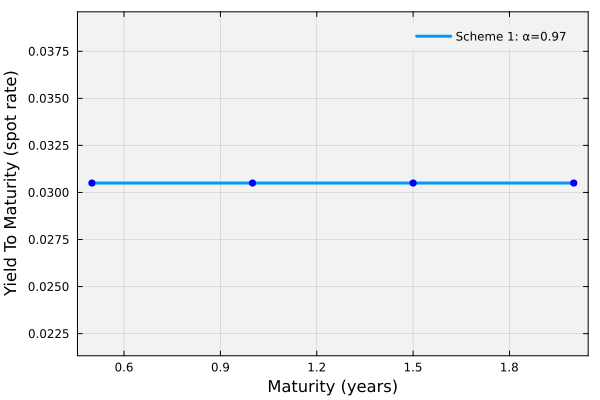

In [12]:
# Plot the Scheme 1 spot yields against maturity.
let
    # Exclude the final principal strip, which shares the last coupon's maturity.
    plot(strips_table_data_array_S1[1:end-1,2], round.(strips_table_data_array_S1[1:end-1,5], digits=4),lw=3,
        label="Scheme 1: α=$(α)", ylims=(0.70*strips_table_data_array_S1[1,5], 1.3*strips_table_data_array_S1[1,5]))
    scatter!(strips_table_data_array_S1[1:end-1,2], round.(strips_table_data_array_S1[1:end-1,5], digits=4), 
    label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield To Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

#### Reassembly check for Scheme 1
How does the sum of the hypothetical STRIPS prices compare with the parent bond value? If the separated claims exactly reproduce the parent's Treasury cash flows, no-arbitrage requires their executable market values to add to the parent dirty value, apart from transaction, financing, and operational costs. A gap produced by our independently chosen pricing rule diagnoses internally inconsistent assumptions; it is not a guaranteed dealer profit.

In [13]:
# Compare the Scheme 1 component total with the intact parent value.
let
    # Compare the intact parent value with the sum of the hypothetical component prices.
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S1[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 99.91501806363222 USD; hypothetical component sum: 102.99572653233072 USD


#### Summary Scheme 1 Pricing
* The constant yield (Scheme 1) pricing approach gives a constant yield curve and a decreasing discount. The short-maturity zeros are more expensive relative to their face value than the long-maturity zeros.
* The observed yield $\bar{Y}$ decreases as the escalation parameter $\alpha$ increases; smaller values of $\alpha$ lead to higher yields $\bar{Y}$. On the other hand, larger values of $\alpha$ increase the discount, i.e., the price of the zero relative to its face value.
* For the selected parameter values, the hypothetical component prices sum to more than the model parent price. In a frictionless market this would violate the reassembly condition and invite arbitrage until prices adjust. It should not be interpreted as a freely available stripping profit.

Next, let's explore Scheme 2.

### Scheme 2: Constant discount STRIPS
Now, let's consider Scheme 2, which has a constant discount, i.e., the ratio of the price to the instrument's face value is constant. We'll use the same value of the escalation parameter $\alpha$ and procedure as the previous Scheme 1 calculation, except we remove the time dependence on the `d` variable. The rebuilt schedule again lands in the `strips::Dict{Int, MyUSTreasuryZeroCouponBondModel}` dictionary:

In [14]:
# Price Scheme 2 strips with a constant price-to-face ratio and infer their yields.
strips = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model)
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # Each dictionary value is one coupon or principal zero-coupon model.
        model = v;
        T = model.T # years to this strip's payment date
        Vₚ = model.par; # strip face value in USD
        d = (α); # Scheme 2 uses one price-to-face ratio at every maturity.
        model.price = (d)*Vₚ

        (ytm, ytm_estimates) = yieldtomaturity(model;
            TR = T,
            price = model.price,
            ϵ = 1e-10,
            maxiter = 1000,
        );
    
        # Store the yield that reproduces the assigned strip price.
        model.rate = ytm;
    end
    strips # Return the priced strip dictionary.
end

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 5 entries:
  5 => MyUSTreasuryZeroCouponBondModel(100.0, 0.0152296, 2.0, 97.0, 2, nothing,…
  4 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0152296, 2.0, 2.24313, 2, noth…
  2 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0304592, 1.0, 2.24313, 2, noth…
  3 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0203061, 1.5, 2.24313, 2, noth…
  1 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0609184, 0.5, 2.24313, 2, noth…

#### Visualize the first $m$ STRIPS products
`Unhide` the code cell to see how we build a table displaying the bond price information. 

> __What's happening in this code?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips` dictionary using the bracket notation `strips[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array_S2::Array{Any,2}` variable and display the resulting table by calling the [`pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/) exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl).

What do you see?

In [15]:
# Build the Scheme 2 audit table with the same columns used for Scheme 1.
strips_table_data_array_S2 = let


    number_of_strips = length(strips);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips # limit the displayed rows
    # Columns store strip index, maturity (years), face value (USD), price (USD), decimal yield, and price/face.
    strips_table_data_array = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips[i];
        strips_table_data_array[i,1] = i
        strips_table_data_array[i,2] = zc_model.T
        strips_table_data_array[i,3] = zc_model.par
        strips_table_data_array[i,4] = zc_model.price
        strips_table_data_array[i,5] = zc_model.rate  
        strips_table_data_array[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array; # Return all rows for plotting and reassembly checks.
end;

==== ========== ======== ========= =========== =============
      Maturity     Face     Price           y     Discount 
            YR      USD       USD               price/face 
==== ========== ======== ========= =========== =============
  1        0.5   2.3125   2.24313   0.0609184         0.97
  2        1.0   2.3125   2.24313   0.0304592         0.97
  3        1.5   2.3125   2.24313   0.0203061         0.97
  4        2.0   2.3125   2.24313   0.0152296         0.97
  5        2.0    100.0      97.0   0.0152296         0.97
==== ========== ======== ========= =========== =============


`Unhide` the code cell to see how we plot the yield curve suggested by your choice of the $\alpha$ parameter.

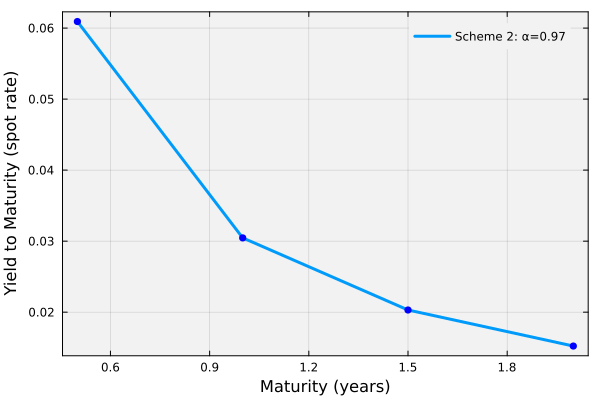

In [16]:
# Plot the Scheme 2 spot yields against maturity.
let
    # Exclude the final principal strip, which shares the last coupon's maturity.
    plot(strips_table_data_array_S2[1:end-1,2], strips_table_data_array_S2[1:end-1,5],lw=3,
        label="Scheme 2: α=$(α)")
    scatter!(strips_table_data_array_S2[1:end-1,2], strips_table_data_array_S2[1:end-1,5], 
        label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield to Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

#### Reassembly check for Scheme 2
Compare the sum of the hypothetical component prices with the parent dirty value. Any difference reflects the fact that Scheme 2 imposes component prices independently of the parent. Executable no-arbitrage prices, before market frictions, must satisfy the reassembly identity.

In [17]:
# Compare the Scheme 2 component total with the intact parent value.
let
    # Compare the intact parent value with the sum of the hypothetical component prices.
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S2[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 99.91501806363222 USD; hypothetical component sum: 105.9725 USD


#### Summary Scheme 2 Pricing
* The constant discount (Scheme 2) pricing approach gives an inverted yield curve. Under Scheme 2, short-maturity zeros yield more than longer-maturity zeros.
* The observed yield $\bar{Y}$ decreases as the escalation parameter $\alpha$ increases; smaller values of $\alpha$ lead to higher yields $\bar{Y}$. On the other hand, under this scheme, the discount is constant.
* The imposed constant-discount rule generates relative prices and yields that need not be consistent with the parent bond or with market STRIPS quotes. The short- versus long-maturity comparisons are properties of this hypothetical parameterization, not cash flows paid by or collected from Treasury.

Finally, let's explore Scheme 3.

### Scheme 3: Varying yield STRIPS
In this scheme, we allow the yield to vary with the maturity of the bond. Suppose the yield at which we are willing to sell the bond is given by:
$$
\bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}
$$
where $i$ is the index of the strip (a proxy for the maturity). Let's set values for the parameters $\theta_{1},$ $\theta_{2},$ and $\beta$:

In [18]:
# Scheme 3 sets the decimal yield at strip index k to θ₁ + θ₂(k - 1)^β.
θ₁, θ₂, β = 0.015, 0.001, 0.5;

We use the same procedure as before, except we compute the yield specified by the equation above, and then we compute the price from the yield using continuous compounding. The result is stored in the `strips_S3::Dict{Int, MyUSTreasuryZeroCouponBondModel}` dictionary:

In [19]:
# Assign a maturity-varying yield to each strip and price it continuously.
strips_S3 = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model);
    discount_model = ContinuousCompoundingModel(); # same continuous-compounding convention used by yieldtomaturity(...)
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # Dictionary key k starts at 1, so k - 1 starts the yield curve at θ₁.
        model = v;
        T = model.T # years to this strip's payment date
        Vₚ = model.par; # strip face value in USD
        Ȳ = θ₁ + θ₂*(k-1)^β; # nominal decimal yield assigned by Scheme 3

        model.rate = Ȳ
        model |> discount_model; # populate price and discount fields
        strips[k] = model; # retain the priced model at the same strip index
    end
    strips; # Return the priced Scheme 3 strip dictionary.
end;

What do the priced Scheme 3 models look like?

In [20]:
# Display the complete Scheme 3 strip dictionary for inspection.
strips_S3

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 5 entries:
  5 => MyUSTreasuryZeroCouponBondModel(100.0, 0.017, 2.0, 96.6572, 2, Dict(0=>-…
  4 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0167321, 2.0, 2.23639, 2, Dict…
  2 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.016, 1.0, 2.27579, 2, Dict(0=>…
  3 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.0164142, 1.5, 2.25626, 2, Dict…
  1 => MyUSTreasuryZeroCouponBondModel(2.3125, 0.015, 0.5, 2.29522, 2, Dict(0=>…

#### Visualize the first $m$ STRIPS products
`Unhide` the code cell to see how we build a table displaying the bond price information. 

> __What's happening in this code?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips_S3` dictionary using the bracket notation `strips_S3[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array_S3::Array{Any,2}` variable and display the resulting table by calling the [`pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/) exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl).

What do you see?

In [21]:
# Build the Scheme 3 audit table with the same six columns as Schemes 1 and 2.
strips_table_data_array_S3 = let

    number_of_strips = length(strips_S3);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips # limit the displayed rows
    # Columns store strip index, maturity (years), face value (USD), price (USD), decimal yield, and price/face.
    strips_table_data_array = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips_S3[i];
        strips_table_data_array[i,1] = i
        strips_table_data_array[i,2] = zc_model.T
        strips_table_data_array[i,3] = zc_model.par
        strips_table_data_array[i,4] = zc_model.price
        strips_table_data_array[i,5] = zc_model.rate  
        strips_table_data_array[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array; # Return all rows for plotting and reassembly checks.
end;

==== ========== ======== ========= =========== =============
      Maturity     Face     Price           y     Discount 
            YR      USD       USD               price/face 
==== ========== ======== ========= =========== =============
  1        0.5   2.3125   2.29522       0.015     0.992528
  2        1.0   2.3125   2.27579       0.016     0.984127
  3        1.5   2.3125   2.25626   0.0164142     0.975679
  4        2.0   2.3125   2.23639   0.0167321      0.96709
  5        2.0    100.0   96.6572       0.017     0.966572
==== ========== ======== ========= =========== =============


`Unhide` the code cell to see how we plot the yield curve suggested by your choice of the $\theta_{1},$ $\theta_{2},$ and $\beta$ parameters.

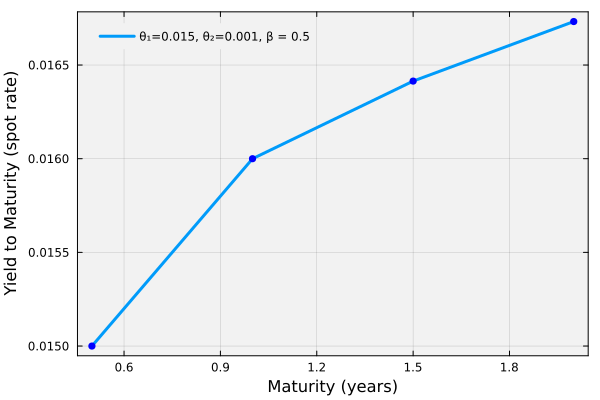

In [22]:
# Plot the Scheme 3 spot yields against maturity.
let

    # Exclude the final principal strip, which shares the last coupon's maturity.
    plot(strips_table_data_array_S3[1:end-1,2], strips_table_data_array_S3[1:end-1,5],lw=3,
    label="θ₁=$(θ₁), θ₂=$(θ₂), β = $(β)")
    scatter!(strips_table_data_array_S3[1:end-1,2], strips_table_data_array_S3[1:end-1,5], 
    label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield to Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

#### Curious: How much would we collect from selling the STRIPS?
In this scenario, we purchased the parent instrument from the [United States Treasury](https://www.treasurydirect.gov/) at auction, stripped the coupons and face value, and sold the components at the Scheme 3 prices. The code below compares the parent value with the sum of the hypothetical component prices:

In [23]:
# Compare the Scheme 3 component total with the intact parent value.
let
    # Compare the intact parent value with the sum of the hypothetical component prices.
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S3[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 99.91501806363222 USD; hypothetical component sum: 105.72081919086263 USD


#### Summary Scheme 3 Pricing
* The varying yield (Scheme 3) pricing approach creates an upward-sloping yield curve where longer-maturity bonds have higher yields than shorter-maturity bonds. This reflects a more realistic market structure.
* The yield for each STRIP is determined by the formula $\bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}$, which allows for flexible control over the yield curve shape through the parameters $\theta_{1}$, $\theta_{2}$, and $\beta$.
* An upward-sloping curve may resemble some market snapshots, but shape alone does not make the prices market-consistent or reveal investor expectations. Before interpreting the component sum as dealer revenue or profit, enforce the parent-bond reassembly identity and include transaction, financing, inventory, and operational costs.

___

## Summary

This example separated the coupon and principal payments of a Treasury security into individually marketable zero-coupon STRIPS and priced those claims under alternative discounting assumptions.

> __Key Takeaways:__
>
> * __Stripping changes packaging, not promised cash flows:__ Each coupon and the principal payment becomes a separate zero-coupon claim with its own maturity date and face value. The parent security's promised payments are unchanged by the separation.
> * __Each STRIP is valued from its own payment date:__ Its price is the present value of one future payment, so maturity and the applicable discount rate determine value. No intermediate coupon payments complicate the calculation.
> * __The assumed term structure changes relative prices:__ Constant-yield, constant-discount, and maturity-dependent yield schemes assign different values to otherwise identical promised payments at different dates. The component prices sum to the parent value only when the assumed rates are consistent with the parent's own pricing.

STRIPS pricing therefore makes the role of the yield curve explicit: separating the cash flows exposes how discount rates at individual maturities determine value.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.